# Кластеризация запросов для разметки типов искажений

**Задача:** применить кластеризацию, чтобы разметить запросы по типам искажений
(опечатки и прочее). Мы заранее НЕ знаем, какие типы там есть — их должно показать
само разбиение на кластеры.

**Как это работает — три честных этапа:**

1. **Векторизация.** Каждый запрос описываем числами, которые говорят про *форму
   строки* (длина, состав алфавита, насколько слова похожи на слова из каталога,
   насколько «обычны» буквосочетания). Это НЕ типы дефектов — это нейтральные
   поверхностные характеристики.
2. **Кластеризация.** `KMeans` сам разбивает запросы на группы по этим числам.
   Каждый запрос получает номер кластера — **это и есть разметка**, её делает алгоритм,
   а не наши `if`-правила.
3. **Интерпретация.** Смотрим на каждый кластер (профиль + примеры) и *называем* его
   человеческим словом (латиница, искажённое слово, норма…). Единственный ручной шаг —
   имя, а не само разбиение.

**Честная оговорка.** Кластеризация группирует по геометрии признаков, поэтому часть
кластеров окажется «нормой» (чистые запросы), а часть — дефектами; и близкие дефекты
(опечатка/мусор/оборванный) могут попасть в один кластер. Что вышло — то и покажем.

In [1]:
import re, math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymorphy3
from rapidfuzz import process, distance
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

morph = pymorphy3.MorphAnalyzer()
DATA_PATH = "../../data.csv"
K = 12                      # число кластеров (подбираем ниже по «локтю»)
pd.set_option("display.width", 220, "display.max_columns", 20)

**Результат:** подключены библиотеки и параметры; число кластеров `K = 12`.

In [2]:
df = pd.read_csv(DATA_PATH)
queries = pd.Series(df["query"].dropna().unique(), name="query")
print(len(queries), "уникальных запросов")
queries.head(8).tolist()

9496 уникальных запросов


['энергетик без сахара',
 'салат из рубца',
 'барилла',
 'краска для волос орех',
 'творог мя',
 'масло детское',
 'холодец э',
 'чипсы эсте']

**Результат:** **9 496** уникальных запросов — объекты кластеризации.

## Шаг 1. Ресурсы из каталога

Из названий товаров и категорий считаем два справочника: частоты **слов** (чтобы
понимать, настоящее ли слово) и частоты символьных **биграмм** (чтобы оценивать,
насколько «обычны» буквосочетания в запросе). Это вспомогательные ресурсы для признаков,
а не типы.

In [3]:
TOKEN_RE = re.compile(r"[а-яёa-z]+", re.IGNORECASE)

def tokenize(text: str) -> list:
    return TOKEN_RE.findall(str(text).lower())

catalog_cols = ["item_name", "category4_name", "category3_name",
                "category2_name", "category1_name"]
word_freq = Counter()
bigram_freq = Counter()
for col in catalog_cols:
    for name in df[col].dropna():
        for w in tokenize(name):
            word_freq[w] += 1
            padded = "^" + w + "$"
            for i in range(len(padded) - 1):
                bigram_freq[padded[i:i + 2]] += 1

CATALOG_WORDS = set(word_freq)
TOTAL_BIGRAMS = sum(bigram_freq.values())
CANDIDATES = [w for w, c in word_freq.items()
              if c >= 3 and len(w) >= 3 and re.fullmatch(r"[а-яё]+", w)]

def is_known(token: str) -> bool:
    if token in CATALOG_WORDS:
        return True
    return bool(re.fullmatch(r"[а-яё]+", token)) and morph.word_is_known(token)

_nearest_cache = {}
def nearest_dist(token: str) -> float:
    """Нормированное расстояние до ближайшего слова каталога (0=совпало, 1=далеко)."""
    if token in _nearest_cache:
        return _nearest_cache[token]
    m = process.extractOne(token, CANDIDATES,
                           scorer=distance.Levenshtein.normalized_distance)
    _nearest_cache[token] = m[1]
    return m[1]

def oddness(text: str) -> float:
    """Средняя «неожиданность» символьных биграмм строки (выше = необычнее)."""
    s = "^" + re.sub(r"[^а-яё]", "", text.lower()) + "$"
    if len(s) < 2:
        return 0.0
    return float(np.mean([-math.log((bigram_freq[s[i:i + 2]] + 1) / TOTAL_BIGRAMS)
                          for i in range(len(s) - 1)]))

print("слов в каталоге:", len(word_freq), "| биграмм:", len(bigram_freq))

слов в каталоге: 25227 | биграмм: 1655


**Результат:** готовы справочники каталога: **25 227** слов и модель символьных биграмм; плюс функции `is_known`, `nearest_dist`, `oddness` для расчёта признаков.

## Шаг 2. Векторизация — поверхностные признаки формы

Каждый запрос → 10 чисел, описывающих КАК он выглядит (не о чём он). Важно: среди них
нет признака «это латиница» или «это опечатка» — только нейтральные характеристики,
из которых кластеризация сама решит, что похоже, а что нет.

In [4]:
CYR = re.compile(r"[а-яё]")
LAT = re.compile(r"[a-z]")
VOWELS = set("аеёиоуыэюя")

def surface_features(query: str) -> dict:
    s = str(query).lower()
    toks = tokenize(s)
    letters = [c for c in s if c.isalpha()] or [""]
    unknown = [t for t in toks if not is_known(t)]
    edits = [nearest_dist(t) for t in unknown if re.fullmatch(r"[а-яё]+", t)]
    cyr = [c for c in s if CYR.match(c)]
    max_run = max((len(m.group(0)) for m in re.finditer(r"(.)\1*", s)), default=1)
    return {
        "query": query,
        "n_chars": len(s),
        "n_tokens": len(toks),
        "mean_tok_len": float(np.mean([len(t) for t in toks] or [0])),
        "frac_latin": sum(bool(LAT.match(c)) for c in letters) / len(letters),
        "frac_digit": sum(c.isdigit() for c in s) / (len(s) or 1),
        "frac_vowel": sum(c in VOWELS for c in cyr) / (len(cyr) or 1),
        "max_char_run": max_run,
        "dict_coverage": (len(toks) - len(unknown)) / (len(toks) or 1),
        "mean_edit_dist": float(np.mean(edits)) if edits else 0.0,
        "oddness": oddness(s),
    }

FEATURES = ["n_chars", "n_tokens", "mean_tok_len", "frac_latin", "frac_digit",
            "frac_vowel", "max_char_run", "dict_coverage", "mean_edit_dist", "oddness"]

F = pd.DataFrame(surface_features(q) for q in queries)
print(F.shape)
F.head()

(9496, 11)


,query,n_chars,n_tokens,mean_tok_len,frac_latin,frac_digit,frac_vowel,max_char_run,dict_coverage,mean_edit_dist,oddness
0,энергетик без сахара,20,3,6.0,0.0,0.0,0.444444,1,1.0,0.000000,6.864544
1,салат из рубца,14,3,4.0,0.0,0.0,0.416667,1,1.0,0.000000,6.217592
2,барилла,7,1,7.0,0.0,0.0,0.428571,2,1.0,0.000000,5.836807
3,краска для волос орех,21,4,4.5,0.0,0.0,0.388889,1,1.0,0.000000,5.884998
4,творог мя,9,2,4.0,0.0,0.0,0.375000,1,0.5,0.333333,6.066238


**Результат:** таблица **9 496 × 10** поверхностных признаков — каждый запрос стал вектором чисел, не привязанным ни к теме, ни к заранее заданному типу.

### Что за признаки

| признак | смысл |
|---|---|
| `n_chars` | длина в символах |
| `n_tokens` | число слов |
| `mean_tok_len` | средняя длина слова |
| `frac_latin` | доля латинских букв |
| `frac_digit` | доля цифр |
| `frac_vowel` | доля гласных (среди кириллицы) |
| `max_char_run` | самый длинный повтор одного символа |
| `dict_coverage` | доля слов, известных каталогу |
| `mean_edit_dist` | среднее расстояние неизвестных слов до эталона |
| `oddness` | необычность буквосочетаний (модель биграмм каталога) |

## Шаг 3. Стандартизация

Признаки в разных масштабах (длина ~2–49, доли 0–1). `StandardScaler` приводит их к
единому масштабу, иначе «большие» числа перевесят при подсчёте расстояний.

In [5]:
X = StandardScaler().fit_transform(F[FEATURES])
print("матрица для кластеризации:", X.shape)

матрица для кластеризации: (9496, 10)


**Результат:** матрица **9 496 × 10** в едином масштабе — вход для KMeans.

## Шаг 4. Сколько кластеров? — метод «локтя»

KMeans требует заранее задать число кластеров `K`. Смотрим, как падает
внутрикластерный разброс (inertia) с ростом `K`, и берём точку, после которой падение
замедляется («локоть»).

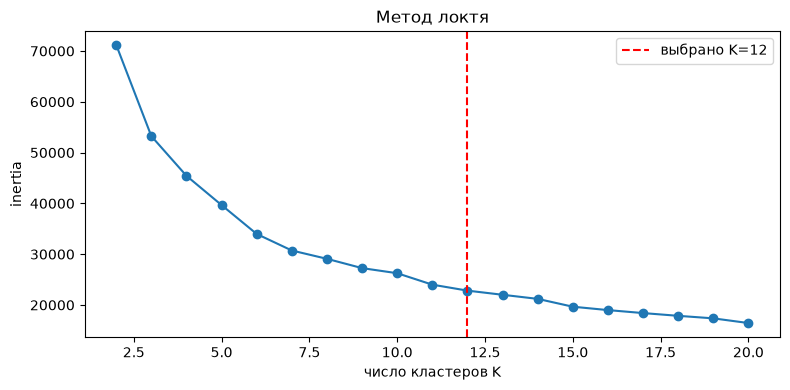

In [6]:
inertias = [KMeans(n_clusters=k, random_state=42, n_init=5).fit(X).inertia_
            for k in range(2, 21)]
plt.figure(figsize=(8, 4))
plt.plot(range(2, 21), inertias, marker="o")
plt.axvline(K, color="red", ls="--", label=f"выбрано K={K}")
plt.xlabel("число кластеров K"); plt.ylabel("inertia"); plt.legend()
plt.title("Метод локтя"); plt.tight_layout()
plt.savefig("elbow.png", dpi=120); plt.show()

**Результат:** график `elbow.png`: после ~10–12 кластеров кривая заметно выполаживается — берём `K = 12`.

## Шаг 5. Кластеризация (разметка)

`KMeans` разбивает 9 496 запросов на `K` групп. Номер кластера, который получает
запрос, — это и есть его метка. Никаких `if`-правил: группировку делает алгоритм.

In [7]:
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
F["cluster"] = kmeans.labels_
F["cluster"].value_counts().sort_index()

cluster
0      458
1     2163
2     1565
3     1243
4      646
5     1239
6       16
7     1029
8      138
9      623
10     234
11     142
Name: count, dtype: int64

**Результат:** каждый из 9 496 запросов получил номер кластера (0…11) — черновая разметка готова.

## Шаг 6. Интерпретация кластеров

Смотрим средний профиль признаков каждого кластера и примеры запросов — чтобы понять,
что за группу собрал алгоритм.

In [8]:
profile = F.groupby("cluster")[FEATURES].mean().round(2)
profile["size"] = F["cluster"].value_counts()
profile

,n_chars,n_tokens,mean_tok_len,frac_latin,frac_digit,frac_vowel,max_char_run,dict_coverage,mean_edit_dist,oddness,size
cluster,,,,,,,,,,,
0,6.59,1.30,5.09,1.00,0.00,0.00,1.00,0.55,0.00,16.08,458
1,11.22,2.25,4.47,0.04,0.00,0.40,1.00,0.99,0.00,6.19,2163
2,6.87,1.00,6.87,0.00,0.00,0.39,1.00,0.00,0.28,6.34,1565
3,5.75,1.00,5.74,0.00,0.00,0.41,1.00,1.00,0.00,5.92,1243
4,15.79,2.22,6.76,0.07,0.00,0.41,2.01,0.96,0.01,6.06,646
5,15.14,1.83,8.02,0.02,0.00,0.42,1.00,0.97,0.01,5.91,1239
6,6.06,0.94,2.62,0.62,0.51,0.16,1.38,0.94,0.00,12.81,16
7,22.33,3.47,5.77,0.04,0.00,0.41,1.02,0.99,0.00,6.15,1029
8,10.19,1.41,5.20,0.07,0.18,0.40,1.17,0.96,0.01,6.21,138


**Результат:** профиль показывает «характер» каждого кластера: напр. `frac_latin≈1` — латиница, `dict_coverage≈0` + `mean_edit_dist>0` — искажённые слова, `frac_digit>0` — с числами.

In [9]:
for cid in range(K):
    ex = F[F["cluster"] == cid]["query"].head(12).tolist()
    print(f"[{cid:>2}] n={ (F['cluster']==cid).sum():>4}  " + " | ".join(map(str, ex)))

[ 0] n= 458  duluth | grands | rich | pici | h m | brit | himalaya herbals | hunters | choco | laroche | nuts | crusty
[ 1] n=2163  салат из рубца | масло детское | холодец э | чипсы эсте | растров для линз | корм для котят | сырок с печенье | свой у | салаты без жира | ром до | тушенка снов | кока кола а4
[ 2] n=1565  туал | нашуники | кисломи | шима | кутба | соломкс | кокт | капто | пергма | баэ | мультизлаков | ростиб
[ 3] n=1243  черкашин | бриошь | вязания | тапки | тертые | голень | сулугуни | креветки. | ольхи | тампоны | куриная | брови
[ 4] n= 646  барилла | котлеты охлажденное | лапша домашняя | круассан самокат | прокладка белла | помидорки черри | даниссимо ими | улитка  с корицей | ароматический диффузор | черри томаты | икра искусств | вкусное мороженное
[ 5] n=1239  следки мужские | шоколад протеиновы | шпинатные | пузырчатая пленка | селиконовая смазка | тональный | пластиковая лож | женская станки | сырокопченые колбасы | йогурт exponenta | прокладки | ножик канцелярс

**Результат:** примеры по кластерам подтверждают профиль — теперь можно дать каждому кластеру имя.

## Шаг 7. Имена кластеров (единственный ручной шаг)

Читаем профиль и примеры выше и присваиваем каждому кластеру человеческое имя.
Значения ниже — интерпретация того, что реально собрал KMeans; **поправь под себя**,
если прочитаешь кластер иначе.

In [10]:
CLUSTER_NAMES = {
    0: "латиница",
    1: "норма · 2 слова",
    2: "искажённое слово",
    3: "норма · 1 слово",
    4: "норма · удвоенная буква",
    5: "норма · длинные слова",
    6: "код / артикул",
    7: "норма · фраза",
    8: "запрос с числом",
    9: "фраза с искажением",
    10: "искажённое слово · вставки/удвоения",
    11: "латиница · удвоения",
}
F["type"] = F["cluster"].map(CLUSTER_NAMES)
F["type"].value_counts()

type
норма · 2 слова                        2163
искажённое слово                       1565
норма · 1 слово                        1243
норма · длинные слова                  1239
норма · фраза                          1029
норма · удвоенная буква                 646
фраза с искажением                      623
латиница                                458
искажённое слово · вставки/удвоения     234
латиница · удвоения                     142
запрос с числом                         138
код / артикул                            16
Name: count, dtype: int64

**Результат:** кластеры получили имена; в колонке `type` — итоговая разметка запроса по типу (её задало разбиение KMeans, мы лишь назвали группы).

## Шаг 8. Выход

Сохраняем разметку в `query_types.csv` и рисуем распределение типов.

сохранено: 9496 строк → query_types.csv


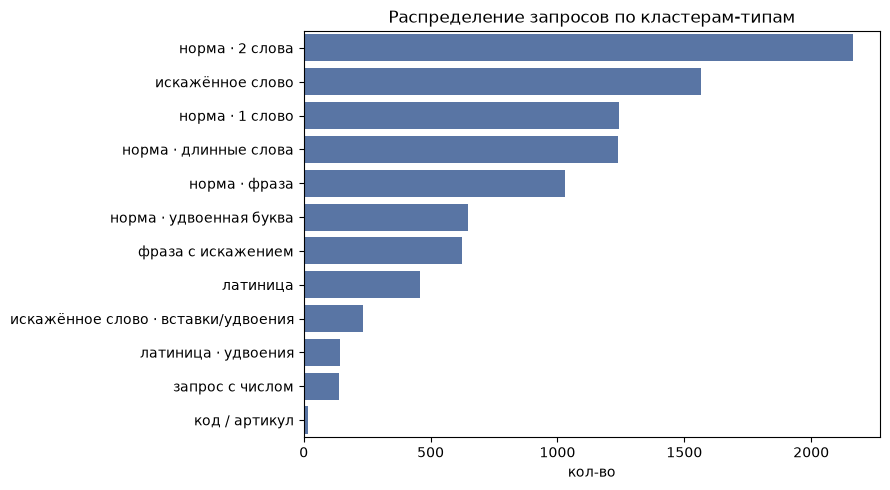

In [11]:
out = F[["query", "cluster", "type"] + FEATURES]
out.to_csv("query_types.csv", index=False)
print("сохранено:", len(out), "строк → query_types.csv")

plt.figure(figsize=(9, 5))
order = F["type"].value_counts().index
sns.countplot(data=F, y="type", order=order, color="#4C72B0")
plt.title("Распределение запросов по кластерам-типам"); plt.xlabel("кол-во"); plt.ylabel("")
plt.tight_layout(); plt.savefig("type_distribution.png", dpi=120); plt.show()

**Результат:** файл `query_types.csv` со всеми 9 496 запросами и их типом + график `type_distribution.png`.

## Шаг 9. Карта кластеров (t-SNE)

Проецируем 10-мерные признаки в 2D, цвет — кластер. Видно, как алгоритм разложил
запросы: обособленные острова (латиница, коды) и более размытые зоны нормы/искажений.

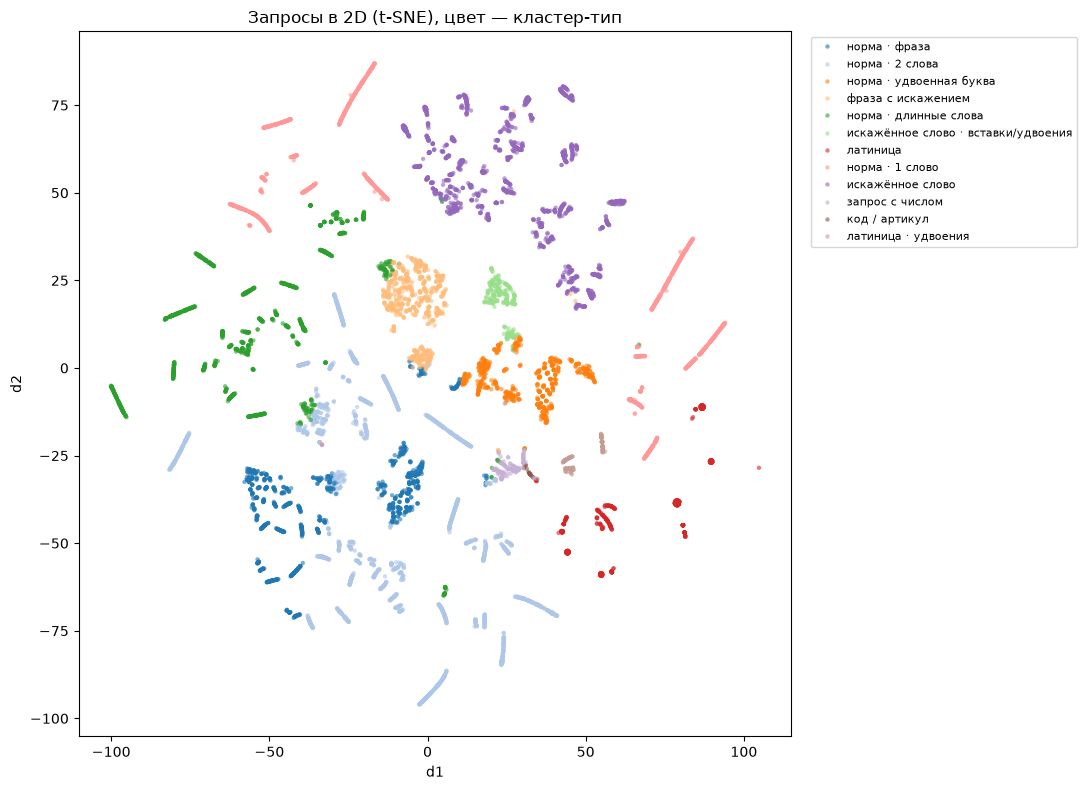

In [12]:
emb = TSNE(n_components=2, perplexity=40, init="pca", random_state=42).fit_transform(X)
F["d1"], F["d2"] = emb[:, 0], emb[:, 1]

plt.figure(figsize=(11, 8))
sns.scatterplot(data=F, x="d1", y="d2", hue="type", s=10, linewidth=0,
                palette="tab20", alpha=0.6)
plt.title("Запросы в 2D (t-SNE), цвет — кластер-тип")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("clusters_2d.png", dpi=120); plt.show()

**Результат:** `clusters_2d.png` — 2D-карта: латиница и коды стоят отдельными островами, норма и искажения занимают соседние зоны.